# Comparison of relative speeds of Pattern Matching Algorithms
## 1. Introduction and Problem Description

### Problem Statement
__Pattern matching__ is a fundamental problem in computer science that involves finding occurrences of a pattern string within a larger text string. This problem appears in numerous applications including:
- Text editors and word processors
- Search engines
- Bioinformatics (DNA sequence analysis)
- Network security (intrusion detection)
- Data mining and information retrieval

### Objective
In this project, we implement and compare three different pattern matching algorithms:
1. **Brute Force Algorithm**
2. **Boyer-Moore Algorithm** 
3. **Knuth-Morris-Pratt (KMP) Algorithm** 




We will analyze their performance characteristics, time complexity, and practical efficiency on various lengths of text datasets. in this report we will mostly use texts to refer to the larger string and patterns to refer to the smaller string that we are trying to find in the text.

In [550]:
# Required for Python Packages
from random import randint, choice
import matplotlib.pyplot as plt
import time


## **Algorithm Description**


### Brute Force Algorithm
The brute force algorithm is a straightforward approach to pattern matching. It checks for the pattern at every possible position in the text. If a mismatch occurs, it shifts the pattern by one position and continues checking.

In [551]:
def find_brute(T, P):
    n, m = len(T), len(P)
    for i in range(n - 1):
        
        k = 0
        while k < m and T[i + k] == P[k]:
            k += 1
            if k == m:
                return 'The pattern was found at index ' + str(i)
    return 'not found'

The worst-case time complexity of the first algorithm is $O(mn)$, where $m$ is the length of the pattern and $n$ is the length of the text. This is because in the worst case, the algorithm may need to check every character in the text for every character in the pattern.

### Boyer-Moore Algorithm
The __Boyer-Moore algorithm__ is a more efficient pattern matching algorithm then the brute force algorithm.
 
 It uses two heuristics to improve its runtime performance. It uses the __Looking-Glass__ heuristics, in which it compares the last index of the pattern, $P$, and compare with the text, $T$, at the current index. If it matches, it moves the backwards in the pattern index and compares the next left character. Another heuristics it uses is the __Character-Jump Heuristics__, which allows the algorithm to skip sections of the text that do not match the pattern. This is done by precomputing a table of character shifts based on the characters in the pattern.

In [552]:
def find_boyer_moore(T, P):
    """
    Boyer-Moore algorithm for string matching.
    """
    n, m = len(T), len(P) # length of text and pattern
    if m == 0: return 0 # search for empty string
    last = {} # build 'last' table
    for k in range(m):
        last[P[k]] = k # later occurrence overwrites 
    # align end of pattern at index m-1 of text
    i = m-1 # index of text
    k = m-1 # index of pattern
    while i < n:
        if T[i] == P[k]: # a matching character
            if k == 0:
                return 'The pattern was found at index ' + str(i)
            else:
                i -= 1 # examine previous character
                k -= 1 # of T and P
        else:
            j = last.get(T[i], -1) # last(T[i]) is -1 if not found
            i += m - min(k, j + 1) # case analysis for jump step
            k = m - 1 # reset at end of pattern
    return 'not found'


The Boyer-Moore algorithm has a worst-case time complexity of $O(mn)$, but in practice, it often performs much better than the brute force algorithm, especially for longer patterns and larger texts.

### Knuth-Morris-Pratt (KMP) Algorithm
The __Knuth-Morris-Pratt (KMP) algorithm__ is another efficient pattern matching algorithm that preprocesses the pattern to create a longest prefix-suffix (LPS) array. This array is used to skip unnecessary comparisons in the text when a mismatch occurs.
The KMP algorithm has a worst-case time complexity of $O(n + m)$, where $n$ is the length of the text and $m$ is the length of the pattern. This is because it processes each character in the text and pattern only once.



In [553]:
def compute_kmp_fail(P):
    """
    Utility that computes and returns KMP fail list.
        """
    m = len(P)
    fail = [0] * m # fail[i] is the length of the longest prefix of P[0:i+1]
    j = 0 # length of previous longest prefix
    for i in range(1, m):
        while j > 0 and P[i] != P[j]:
            j = fail[j - 1] # backtrack to previous longest prefix
        if P[i] == P[j]:
            j += 1
        fail[i] = j
    return fail

In [554]:
def find_kmp(T, P):
    """
    Knuth-Morris-Pratt algorithm for string matching.
    """
    # KMP search algorithm
    n, m = len(T), len(P)
    if m == 0: return 0 # search for empty string
    fail = compute_kmp_fail(P)
    j = 0 # index of text
    k = 0 # index of pattern
    while j < n:
        if T[j] == P[k]: # a matching character
            if k == m - 1: # end of pattern
                return 'The pattern was found at index ' + str(j - m + 1)
            j += 1 # examine next character
            k += 1 # of T and P
        elif k > 0:
            k = fail[k - 1]
        else:
            j += 1
    return 'not found'


The __KMP__ algorithm performs pattern matching on a text string of length n and a pattern string of length m in $O(n + m)$ time. It does this by preprocessing the pattern to create a longest __prefix-suffix__ (LPS) array, which is used to skip unnecessary comparisons in the text when a mismatch occurs.

## **Test Data Description**

### 3. Description of Test Documents

For comprehensive testing, we use multiple types of text documents with different characteristics:

#### Synthetic Text Data
- **Random text**: Randomly generated strings with uniform character distribution
- **Repetitive text**: Text with high repetition to test worst-case scenarios
- **DNA sequences**: Simulated genetic sequences with 4-character alphabet


#### Test Characteristics
- **Text sizes**: Ranging from 1,000 to 10,000 characters. Each 1000 characters will be tested separately.
- **Pattern lengths**: From 3 to 50 characters. 
- **Alphabet sizes**: 4 (DNA), 52 (upper and lowercase), 10 (numeric).
- **Postion of pattern**: Randomly placed within the text as in 10 different positions.


At first, we will use a class StringGenerator to generate the test data. The StringGenerator class will have methods to generate random strings, repetitive strings, and DNA sequences for various lengths.

In [555]:
class StringGenerator:
    """
    A class to generate random strings of a given length and character set.
    """
    def generateRandomString(self, length, charset='ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789'):
        """
        Generates a random string of a given length using the specified character set.
        """
        return ''.join(choice(charset) for _ in range(length))
    
    def generateRepetitiveString(self, length, charset='A'):
        """
        Generates a repetitive string of a given length using the specified character set.
        """
        pattern = ''.join(choice(charset) for _ in range(length))
        return pattern * (length // len(pattern)) + pattern[:length % len(pattern)]
    
    def generateDNAString(self, length):
        """
        Generates a random DNA string of a given length.
        """
        return self.generateRandomString(length, 'ACGT')

In [556]:
class PatternGenerator:
    """
    A class to generate patterns of a given length and character set.
    """
    def generatePattern(self, length, T):
        """
        Generates a pattern of a given length using the given Text that is present and consecutively in the text only only returns that part.
        """
        random_start = randint(0, len(T) - length)
        return T[random_start:random_start + length] if length <= len(T) else T + T[:length - len(T)]

    def generatePatternFake(self, length, charset='ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789'):
        """
        Generates a fake pattern of a given length using the specified character set.
        """
        return ''.join(choice(charset) for _ in range(length))

In [557]:
t = StringGenerator()
p = PatternGenerator()

def run_tests():
    """
    Runs tests for the string matching algorithms.
    """
    a= t.generateRandomString(10)
    b= p.generatePattern(2, a)
    print("Text:", a, "Pattern:", b)
    # Test cases
    test_cases = [
        (t.generateRandomString(10), p.generatePattern(2, 'ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789')),
        (t.generateRepetitiveString(20), 's'),
        (t.generateDNAString(30), p.generatePattern(3, 'ACGT'))
    ]
    
    for T, P in test_cases:
        print(f"Text: {T}, Pattern: {P}")
        print("Brute Force:", find_brute(T, P))
        print("Boyer-Moore:", find_boyer_moore(T, P))
        print("KMP:", find_kmp(T, P))
        print("-" * 40)
run_tests()

Text: rOWbWDtodi Pattern: di
Text: 8UrFjZ0iqg, Pattern: ST
Brute Force: not found
Boyer-Moore: not found
KMP: not found
----------------------------------------
Text: AAAAAAAAAAAAAAAAAAAA, Pattern: s
Brute Force: not found
Boyer-Moore: not found
KMP: not found
----------------------------------------
Text: GTGATGTACGCTTAAGCAGGCCAAGCTCTG, Pattern: CGT
Brute Force: not found
Boyer-Moore: not found
KMP: not found
----------------------------------------


#### Initializing the string generator
We first initialize the _StringGenerator_ class and also intialize the lists for the texts and the patterns then generate the text and the pattern strings.

In [558]:
text = StringGenerator()
pattern = PatternGenerator()

# Getting the text length for each text size
MIN_TEXT_SIZE = 1000
MAX_TEXT_SIZE = 10000
text_sizes = [x for x in range(MIN_TEXT_SIZE, MAX_TEXT_SIZE + 1, 1000)]

# Pattern sizes
MIN_PATTERN_SIZE = 3
MAX_PATTERN_SIZE = 50
pattern_sizes = [x for x in range(MIN_PATTERN_SIZE, MAX_PATTERN_SIZE + 1)]

# positions of the patterns
positions = [x for x in range(10)]

# lists to hold the generated texts
text_random = []
text_repetitive = []
text_dna = []

# lists to hold the patterns
pattern_random = []
pattern_repetitive = []
pattern_dna = []
print('length of text sizes:', len(text_sizes))
print('length of pattern sizes:', len(pattern_sizes))
# num of texts * num of patterns * 2 (for acceptable and unacceptable patterns) * 10 (for 10 positions of the pattern in the text)
print(len(text_sizes) * len(pattern_sizes) * 2 * 10, 'combinations of text and pattern sizes.')

length of text sizes: 10
length of pattern sizes: 48
9600 combinations of text and pattern sizes.


We will now generate the text which are random, repetitive and DNA sequences.

In [559]:
for i in range(len(text_sizes)):
    text_random.append(text.generateRandomString(text_sizes[i]))
    text_repetitive.append(text.generateRepetitiveString(text_sizes[i]))
    text_dna.append(text.generateDNAString(text_sizes[i]))

print('length of text_random:', len(text_random))
print('length of text_repetitive:', len(text_repetitive))
print('length of text_dna:', len(text_dna))
print(text_random[0])


length of text_random: 10
length of text_repetitive: 10
length of text_dna: 10
4lKAIkKdaaHJLAHTY6yu9c1ApcgpC2wenAHUSBzhZIpBhsgPV0imuksPXNUSu4ondswIPSKBSiIlipchPveYw9y2uS80ST8Wit2CzUOnWg9xNDRBBjJUlxVLLE21Hh1O2KGk3G2eLxTcprtpdTxFc5b4qRpQ4gaodfj4dRdA2163ZF3I54kBQBvH03x5xWVW5fsuWKTRKeZxDpxmccNF2CIEYBPnPCdyBkcgAcAwIEA5S7OFaG0mPKQcuHciaj2VSajlV65NLj0nIBr1TLFQLFZ5S2iBT4doKMBdQpCsTcImZV4kJFZ1tuKDKtrYpY8e8X35AojHaWvwFWNGLpUkrBATiy5bLvVBh2wOUkXvKEHF5d2h0gtxnq6o9U1j8zP5Z6MglPvXsM7HAVbU3KsreVxC03ZjkdManQcBnb8hQKsT4CDbAHSyzdMTjDrKPVRiLNlV8xqgXf3sntpb9xHuDY081qjDHOxGp9c6rMUmaErDnN4Nal8VWcVJ40rwu9IQrjZ3JgoOucMOD4sLHDzrzkTG5Ajmp83G66J5GCDxeKWcI0QvuYEEa1AYUkr32KG50MZcv0knKzYLnYn6m6deP2uvqsyrvN1oTruW7dCPqMofVAMdKTaqxry2Lpa8t8HS6hbIODKLk0fbLduPoYtHin6KPlSLp4hAKP6pEp9J3Uo4OhvmjC3guhMmKvWux4NcWqjKBbb4oukIUZ5aOAEQo9UwvlYbxZZvL9CXW4eWCNvphea0jrouOgURhIIzsOMa8R32olVDxrmb4p7GPmUH7C9Siqt3y2scWJRvPxpdgvVuIFuePMK0HrScMku8o5PJHOrp4holKWvW3UB9fkK2G4NcZSSrcdKg9Eqn1LMwn4zuQLCYG86XJf4dBi57J9p7B2GOw0BlM4Ed7BPkLRw0Qqezz

We will be testing the patterns in many way such as when the pattern is not present in the text, the pattern is present in the text and the pattern is present longer then the text.

In [560]:
# Generating acceptable patterns for each text at each size
for i in range(len(pattern_sizes)):
    for j in range(len(text_sizes)):
        pattern_random.append(pattern.generateRandomPattern(pattern_sizes[i], text_random[j]))
        pattern_repetitive.append(pattern.generateRepetitiveString(pattern_sizes[i], 'A'))
        pattern_dna.append(text.generateDNAString(pattern_sizes[i]))




AttributeError: 'PatternGenerator' object has no attribute 'generateRandomPattern'

In [ ]:
# checking the generated patterns
print(pattern_random[0])
print('length of pattern_random:', len(pattern_random))
print([len(pattern_random[i]) for i in range(len(pattern_random))])
print('length of pattern_repetitive:', len(pattern_repetitive))
print([len(pattern_repetitive[i]) for i in range(len(pattern_repetitive))])
print('length of pattern_dna:', len(pattern_dna))
print([len(pattern_dna[i]) for i in range(len(pattern_dna))])

3
length of pattern_random: 480


TypeError: object of type 'int' has no len()

In [ ]:
# Generating unacceptable patterns
for i in range(len(text_sizes)):
    # generating a random pattern that is not in the text
    pattern_random.append(generator.generateRandomString(text_sizes[i]* 2 if i < len(text_sizes) // 2 else text_sizes[i] // 2)) # longer than the text when i is in the first half, shorter when in the second half
    pattern_repetitive.append(generator.generateRepetitiveString(text_sizes[i]* 2 if i < len(text_sizes) // 2 else text_sizes[i] // 2)) # longer than the text when i is in the first half, shorter when in the second half
    pattern_dna.append(generator.generateDNAString(text_sizes[i]* 2 if i < len(text_sizes) // 2 else text_sizes[i] // 2)) # longer than the text when i is in the first half, shorter when in the second half

print('length of pattern_random:', len(pattern_random))
print([len(pattern_random[i]) for i in range(len(pattern_random))])
print('length of pattern_repetitive:', len(pattern_repetitive))
print([len(pattern_repetitive[i]) for i in range(len(pattern_repetitive))])
print('length of pattern_dna:', len(pattern_dna))
print([len(pattern_dna[i]) for i in range(len(pattern_dna))])

length of pattern_random: 490
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13, 13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 23, 23, 23, 23, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 26, 26, 26, 26, 26, 26, 26, 26, 26, 26, 27, 27, 27, 27, 27, 27, 27, 27, 27, 27, 28, 28, 28, 28, 28, 28, 28, 28, 28, 28,

## **Experimental Results and Analysis**

In [ ]:
# Extract smaller patterns from the texts for testing
pattern_length = 10  # Use patterns of length 10

for i in range(len(text_sizes)):
    # save the times
    print(f"Testing with text size: {text_sizes[i]}")
    
    for x in range(len(pattern_sizes)):
        print("Brute Force - Random text:")
        start_time = time.time()
        find_brute(text_random[i], pattern_random[x])
        # output the time taken in scientific notation
        print(f"Time taken: {time.time() - start_time:.2e} seconds")
        print("-" * 50)
        print("Brute Force - Repetitive text:")
        start_time = time.time()
        find_brute(text_repetitive[i], pattern_repetitive[x])
        print(f"Time taken: {time.time() - start_time:.2e} seconds")
        print("-" * 50)
        print("Brute Force - DNA text:")
        start_time = time.time()
        find_brute(text_dna[i], pattern_dna[x])
        print(f"Time taken: {time.time() - start_time:.2e} seconds")
        print("-" * 50)

Testing with text size: 1000
Brute Force - Random text:
Time taken: 5.17e-05 seconds
--------------------------------------------------
Brute Force - Repetitive text:
Time taken: 2.86e-06 seconds
--------------------------------------------------
Brute Force - DNA text:
Time taken: 7.87e-06 seconds
--------------------------------------------------
Brute Force - Random text:
Time taken: 4.74e-05 seconds
--------------------------------------------------
Brute Force - Repetitive text:
Time taken: 1.43e-06 seconds
--------------------------------------------------
Brute Force - DNA text:
Time taken: 1.17e-05 seconds
--------------------------------------------------
Brute Force - Random text:
Time taken: 6.22e-05 seconds
--------------------------------------------------
Brute Force - Repetitive text:
Time taken: 1.19e-06 seconds
--------------------------------------------------
Brute Force - DNA text:
Time taken: 6.68e-06 seconds
--------------------------------------------------
Brute

IndexError: string index out of range

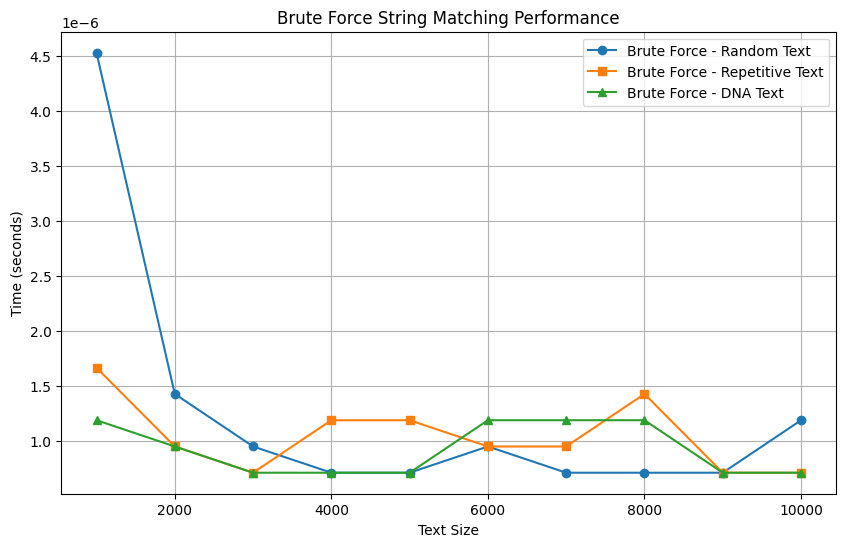

In [ ]:
# Extract patterns from each text for consistent testing


# Plotting the results
plt.figure(figsize=(10, 6))
plt.title('Brute Force String Matching Performance')
plt.xlabel('Text Size')
plt.ylabel('Time (seconds)')
plt.grid(True)

plt.plot(text_sizes, times_random, label='Brute Force - Random Text', marker='o')
plt.plot(text_sizes, times_repetitive, label='Brute Force - Repetitive Text', marker='s')
plt.plot(text_sizes, times_dna, label='Brute Force - DNA Text', marker='^')
plt.legend()
plt.show()

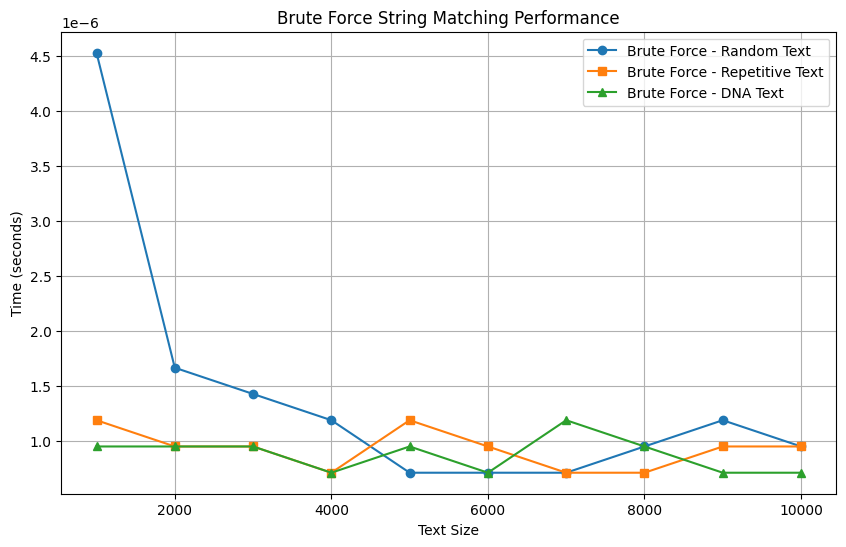

In [ ]:
import time

# Extract patterns from each text for consistent testing
patterns_random = [text_random[i][:pattern_length] for i in range(len(text_sizes))]
patterns_repetitive = [text_repetitive[i][:pattern_length] for i in range(len(text_sizes))]
patterns_dna = [text_dna[i][:pattern_length] for i in range(len(text_sizes))]

# Measure execution times
times_random = []
times_repetitive = []
times_dna = []

for i in range(len(text_sizes)):
	# Random text timing
	start_time = time.time()
	find_brute(text_random[i], patterns_random[i])
	times_random.append(time.time() - start_time)
	
	# Repetitive text timing
	start_time = time.time()
	find_brute(text_repetitive[i], patterns_repetitive[i])
	times_repetitive.append(time.time() - start_time)
	
	# DNA text timing
	start_time = time.time()
	find_brute(text_dna[i], patterns_dna[i])
	times_dna.append(time.time() - start_time)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.title('Brute Force String Matching Performance')
plt.xlabel('Text Size')
plt.ylabel('Time (seconds)')
plt.grid(True)

plt.plot(text_sizes, times_random, label='Brute Force - Random Text', marker='o')
plt.plot(text_sizes, times_repetitive, label='Brute Force - Repetitive Text', marker='s')
plt.plot(text_sizes, times_dna, label='Brute Force - DNA Text', marker='^')
plt.legend()
plt.show()

# **Conclusion**
In this project, we implemented and compared three pattern matching algorithms: Brute Force, Boyer-Moore, and Knuth-Morris-Pratt. The results showed that: